<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-01/trabalho-01/demo_regressaop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

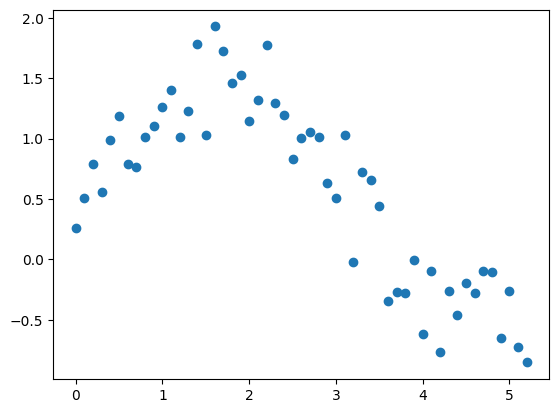

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# a
data = pd.read_csv("data_preg.csv", header=None, names=['x', 'y'])
x = data['x']
y = data['y']

plt.scatter(x, y) # b
plt.show()

In [196]:
from typing import Literal

# Definição de dicionários para armazenar previsões para plotagem e cálculos
y_predictions: dict[Literal['p1', 'p2', 'p3', 'p8', 'p20'], np.ndarray] = {}
y_train_predictions: dict[Literal['p1', 'p2', 'p3', 'p8', 'p20'], np.ndarray] = {}
y_test_predictions: dict[Literal['p1', 'p2', 'p3', 'p8', 'p20'], np.ndarray] = {}

In [197]:
from copy import deepcopy
from typing import Callable

def polynomial_regression(x: np.ndarray, y: np.ndarray, deg: int) -> tuple[np.ndarray, Callable]:
    beta = np.polyfit(x, y, deg)

    # Eleva-se a (deg - i) porque a função polyfit inverte a ordem dos parâmetros em β
    def predict(x: np.ndarray) -> np.ndarray:
        x_poly = np.column_stack([x**(deg - i) for i in range(deg + 1)])
        return x_poly @ beta

    return beta, predict # Retorna β e 𝑦̂

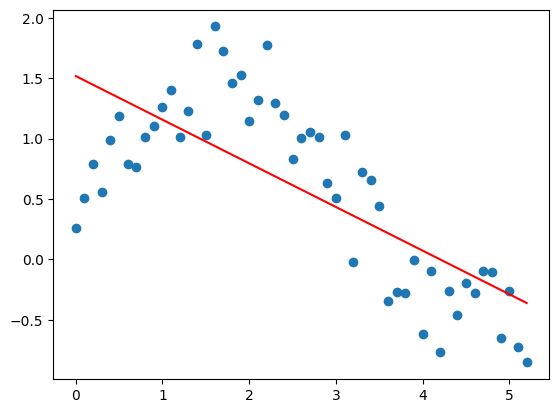

In [198]:
# c)
beta, predict  = polynomial_regression(x, y, 1)

y_predictions['p1'] = predict(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p1'], 'r')
plt.show()

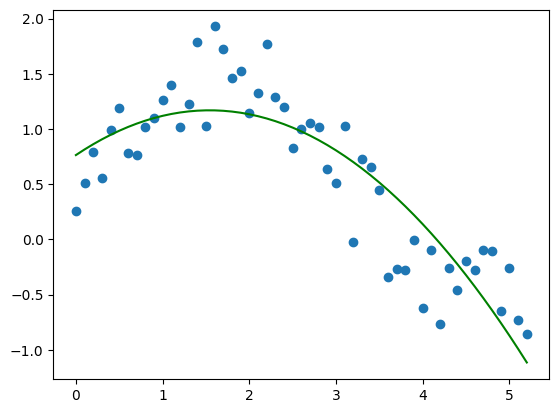

In [199]:
# d)
_, predict = polynomial_regression(x, y, 2)

y_predictions['p2'] = predict(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p2'], 'g')
plt.show()

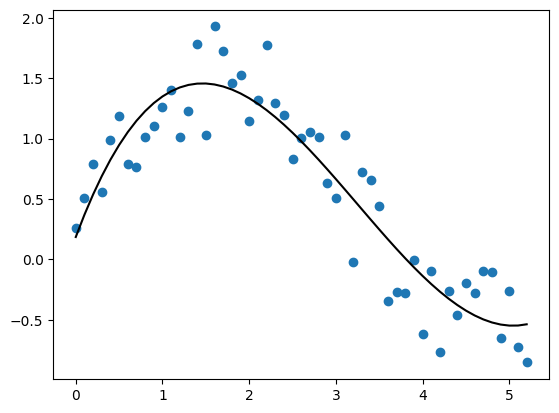

In [200]:
# e)
beta, predict = polynomial_regression(x, y, 3)

y_predictions['p3'] = predict(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p3'], 'black')
plt.show()

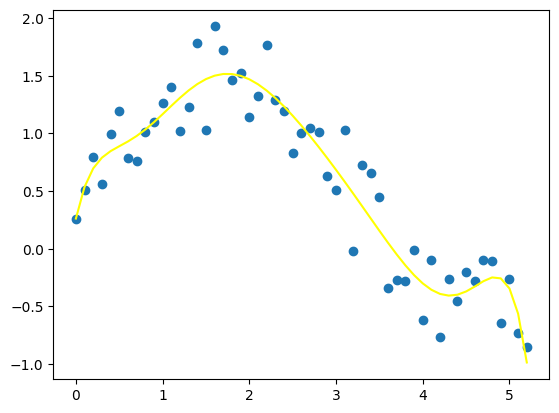

In [201]:
# f)
beta, predict = polynomial_regression(x, y, 8)

y_predictions['p8'] = predict(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p8'], 'yellow')
plt.show()

In [202]:
def residual(y: float, y_hat: float) -> float:
    return (y - y_hat)**2

def residual_sum(y: np.ndarray, y_hat: np.ndarray) -> float:
    return np.sum([residual(y[i], y_hat[i]) for i in range(len(y))])

def eqm(y: np.ndarray, y_hat: np.ndarray) -> float:
    return 1 / len(y) * residual_sum(y, y_hat)

In [203]:
# g)
for key, value in y_predictions.items():
    print(f'EQM {key}:', eqm(y, value))

EQM p1: 0.2659342636924439
EQM p2: 0.13852649027579425
EQM p3: 0.07869725256060663
EQM p8: 0.05870934697374138


**g. Calcule o Erro Quadrático Médio (EQM) para cada linha de regressão. Qual é o mais preciso?**

---

A regressão que apresenta menor valor de EQM, ou seja, mais precisão na previsão, foi a de grau 8, com valor igual a 0.05870934697374138, extremamente baixo.

In [204]:
# h)
def split_train_test(x: np.ndarray, y: np.ndarray, proportion: float) -> tuple[np.ndarray, np.ndarray]:
    full_dataset = np.column_stack((x, y))

    # Aleatoriza os dados
    np.random.shuffle(full_dataset)
    train_size = int(len(full_dataset) * proportion)

    return full_dataset[:train_size], full_dataset[train_size:]

# Divide 90/10
training_set, test_set = split_train_test(x, y, 0.9)

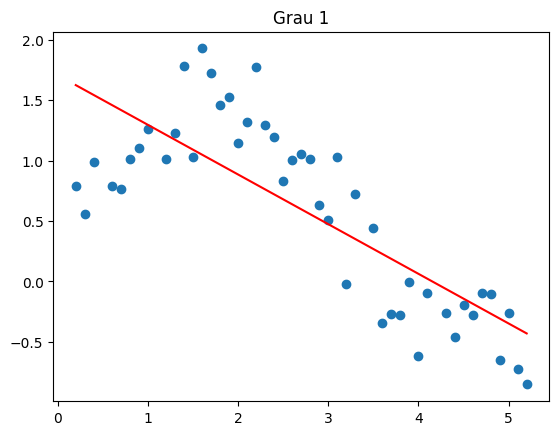

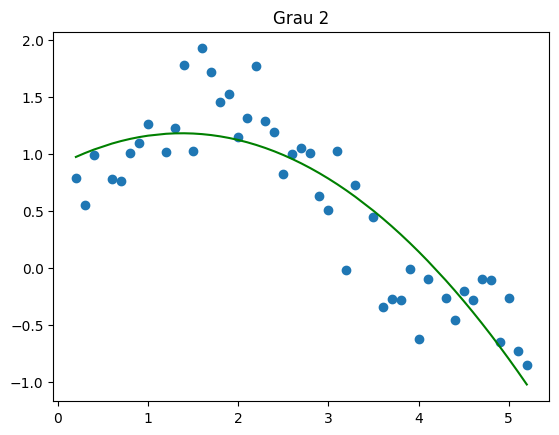

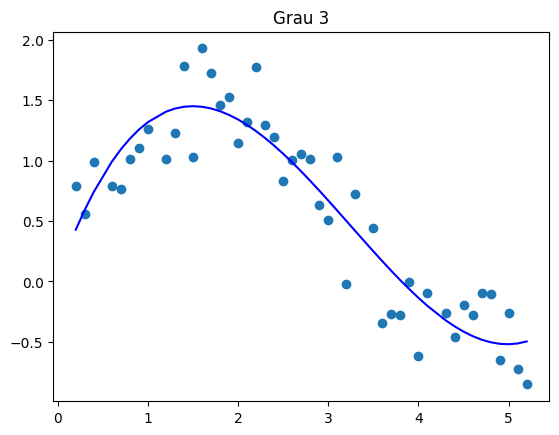

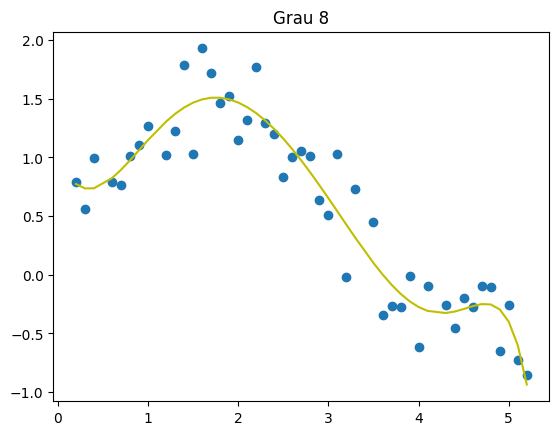

In [205]:
# i)
training_set_x = training_set[:, 0]
training_set_y = training_set[:, 1]

sorted_indexes = np.argsort(training_set_x)
x_sorted = training_set_x[sorted_indexes]

degrees = [1, 2, 3, 8]
colors = ['r', 'g', 'b', 'y']
y_train_predictions = {}

for i, degree in enumerate(degrees):
    key = f'p{degree}'

    _, predict = polynomial_regression(training_set_x, training_set_y, degree)

    y_train_predictions[key] = predict(training_set_x)

    y_sorted = y_train_predictions[key][sorted_indexes]

    plt.scatter(training_set_x, training_set_y)
    plt.plot(x_sorted, y_sorted, colors[i])
    plt.title(f'Grau {degree}')
    plt.show()

In [206]:
# j)
test_set_x = test_set[:, 0]
test_set_y = test_set[:, 1]

degrees = [1, 2, 3, 8]
y_test_predictions = {}

# Calculando as previsões dos dados de teste usando os pesos do treino
for degree in degrees:
    key = f'p{degree}'

    # Obtém matriz de parâmetros 𝛽 com dados de treinamento
    beta_train, predict_train = polynomial_regression(training_set_x, training_set_y, degree)

    y_test_predictions[key] = predict_train(test_set_x)

# Calculando o EQM do teste
for key, value in y_test_predictions.items():
    print(f'EQM {key}:', eqm(test_set_y, value))

EQM p1: 0.7059158532321096
EQM p2: 0.20427584676609495
EQM p3: 0.09513063425715708
EQM p8: 0.21253100070285402


In [207]:
# k)
from sklearn.metrics import r2_score

print('Train')
for key, value in y_train_predictions.items():
    print(f'R² {key}:', r2_score(training_set_y, value))

print('\nTest')
for key, value in y_test_predictions.items():
    print(f'R² {key}:', r2_score(test_set_y, value))


Train
R² p1: 0.620735925891788
R² p2: 0.771073692724558
R² p3: 0.8650030017207516
R² p8: 0.9047139347061657

Test
R² p1: -0.43178488194797326
R² p2: 0.5856743154192252
R² p3: 0.8070498015933723
R² p8: 0.5689306701948155


**k. Calcule o R2 para os dados de treino e teste (veja a função r2_score da biblioteca sklearn.metrics). O que se pode concluir com os resultados?**


---


De modo geral, percebeu-se um desempenho melhor do modelo no treino em todas as execuções (R2 maior), o que sugere uma adequação razoável se comparado a um genérico, ou seja, nem overfitting, nem underfitting. Em relação à diferença de R2 entre treino e teste, a regressão polinomial de grau 3 demonstrou menor divergência — sempre convergindo para algum valor dentro do mesmo intervalo decimal (0.8). Isso significa que esse grau permite maior adaptabilidade do modelo a dados inéditos (generalização), enquanto os demais têm um desempenho reduzido no teste.

 **l. Visto o cálculo do erro e do coeficiente de determinação, qual o modelo mais preciso neste caso? Explique sua resposta.**

---

Apesar dos resultados de EQM sugerirem que a regressão de grau 8 é a melhor no sentido de menor margem de erro, o coeficiente de determinação evidencia uma adequação inferior com dados inéditos (queda de 0.079). Em outras palavras, apesar de demonstrar um erro menor para o dataset de treino, quando aplicado sobre o conjunto de teste, o modelo de grau 8 tem sua performance reduzida, sugerindo overfitting. Graus mais baixos, como 1 e 2, também demonstram pior performance no teste. Já a regressão polinomial de grau 3, ainda que com um valor de R2 menor, apresentou uma variação menor entre teste e treino (0.004), ou seja, é mais precisa por ser mais estável.

/tmp/ipykernel_7207/3194346565.py:5: RankWarning: Polyfit may be poorly conditioned
  beta = np.polyfit(x, y, deg)


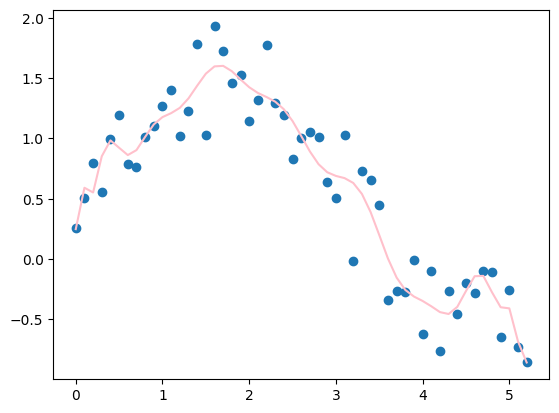

EQM Train: 0.0470523156737473
EQM Test: 809.7580719592827


/tmp/ipykernel_7207/3194346565.py:5: RankWarning: Polyfit may be poorly conditioned
  beta = np.polyfit(x, y, deg)


In [208]:
# m)
# Dataset completo
_, predict = polynomial_regression(x, y, 20)

y_predictions['p20'] = predict(x)

plt.scatter(x, y)
plt.plot(x, y_predictions['p20'], 'pink')
plt.show()

# Treino
_, predict_train = polynomial_regression(training_set_x, training_set_y, 20)
y_train_predictions['p20'] = predict_train(training_set_x)

# Teste
y_test_predictions['p20'] = predict_train(test_set_x)

print('EQM Train:', eqm(training_set_y, y_train_predictions['p20']))
print('EQM Test:', eqm(test_set_y, y_test_predictions['p20']))

**m. Trace a curva de regressão polinomial de grau 20 no gráfico de dispersão dos dados. Compare o comportamento desta curva com os modelos de grau 1, 2, 3 e 8 e analise o erro quadrático médio (EQM) nos dados de treinamento e nos
dados de teste. O modelo de grau 20 apresenta melhor desempenho nos dados de
teste? O que acontece com a forma da curva? Justifique sua resposta.**

---

Visualmente, é possível notar que a curva de grau 20 passa exatamente por alguns dos pontos do dataset, tendo previsões mais próximas ao conjunto de treino do que os modelos de grau menor.

Entretanto, ao analisar o EQM comparativo, percebe-se que, para os dados de treino, a taxa de erro é bastante baixa, mas para o conjunto de teste, é extremamente alta. Isso sugere que o modelo se adequa tão bem aos dados de treino que tem dificuldade de generalizar conhecimento para prever dados inéditos, como se "decorasse" o conteúdo para a prova (overfitting).

Isso reforça o que presumimos nos casos anteriores: o grau 8 já apresentava dificuldade de generalização em relação ao grau 3. Ou seja, seria provável que graus maiores seguissem essa tendência.